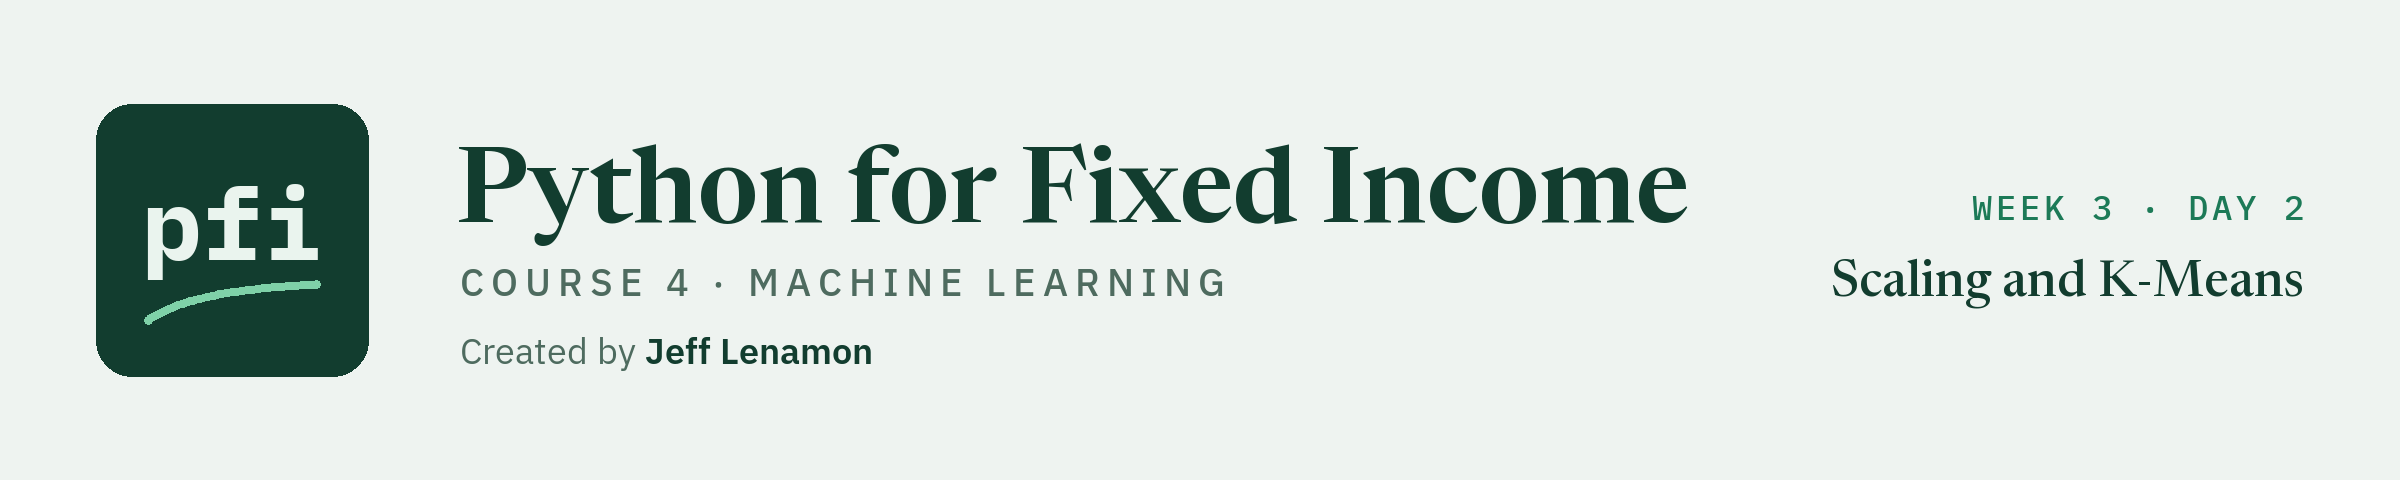

# Scaling and K-Means

Week 3, Day 2. Clustering looks for groups of similar rows when there is no target to fit. Today: why a distance needs scaled columns, K-means step by step, the elbow and the silhouette for choosing the number of clusters as a judgement, and clusters described by their counts and averages.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week3/day2/12_scaling_and_k_means.ipynb)

Days 1 to 11 fitted models to a **target**: a spread, a default flag, a yield. Every model was judged on rows it had not seen, and yesterday's walk-forward folds made sure that, on dated rows, those were later rows. Today there is no target. **Clustering** looks for groups of rows that are similar across several columns at once, and K-means is the method most people meet first.

The rows are the 821 bonds of week 1 again, with four columns: log OAS, duration, coupon, and rating score. **The data is synthetic.** The bonds belong to invented issuers, and their spreads were generated by the course's own script, `tools/make_holdings.py`, from rating, maturity, an issuer effect, and noise. A cluster of these bonds is a group of similar rows in an invented file, and nothing more.

Today you will:

1. Say what changes when a method has no target to fit.
2. Measure the distance between two bonds, and see that the units decide it.
3. Run K-means by hand on ten bonds, then on all 821 bonds in the file's units.
4. Scale the columns with `StandardScaler` and run K-means again.
5. Compute the elbow and the silhouette with a new function, `elbow_table`.
6. Choose the number of clusters as a judgement, with two charts behind it.
7. Describe each cluster by its counts and averages, and never rank one.

Q. Set up today's work folder: the thread settings, the seed, the data files the tests read, and a fresh work folder.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_12_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv", "treasury_par_yields.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_12_i23q_2t9, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv, treasury_par_yields.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])


from sklearn.metrics import roc_curve


def card_split() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """The card file's 60/20/20 split, stratified, seed 42: 18,000 training, 6,000 validation, 6,000 test rows.
    The four person columns (SEX, EDUCATION, MARRIAGE, AGE) and ID are never features."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card[CARD_TARGET]
    X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=SEED)
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def validation_proba() -> tuple[pd.Series, np.ndarray]:
    """Validation outcomes and probabilities of a scaled logistic regression fitted on the training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    return y_valid, model.predict_proba(X_valid)[:, 1]


def test_threshold_for_recall_hand():
    y = [1, 0, 1, 0, 1, 0]
    proba = [0.9, 0.8, 0.7, 0.4, 0.3, 0.1]
    # at 0.7 two of three defaults are caught (recall 2/3); at 0.3 all three
    assert mlkit.threshold_for_recall(y, proba, 0.6) == 0.7
    assert mlkit.threshold_for_recall(y, proba, 0.7) == 0.3
    assert mlkit.threshold_for_recall(y, proba, 1.0) == 0.3
    # tied probabilities are flagged together
    assert mlkit.threshold_for_recall([1, 1, 0, 1], [0.6, 0.5, 0.5, 0.2], 0.5) == 0.5


def test_threshold_meets_target():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    recall = mlkit.classification_metrics(y_valid, (proba >= threshold).astype(int))["recall"]
    assert recall >= 0.70
    # roc_curve flags rows with score >= threshold too: the true positive rate there is the same recall
    # (drop_intermediate=False keeps every distinct probability as a threshold)
    fpr, tpr, thresholds = roc_curve(y_valid, proba, drop_intermediate=False)
    assert tpr[thresholds == threshold][0] == pytest.approx(recall, abs=1e-12)


def test_threshold_is_highest():
    y_valid, proba = validation_proba()
    threshold = mlkit.threshold_for_recall(y_valid, proba, 0.70)
    higher = np.unique(proba[proba > threshold])
    # the next distinct probability above the threshold misses the target
    next_up = higher.min()
    assert mlkit.classification_metrics(y_valid, (proba >= next_up).astype(int))["recall"] < 0.70


def test_threshold_rejects_bad_target():
    for target in (0.0, -0.1, 1.2):
        with pytest.raises(ValueError):
            mlkit.threshold_for_recall([0, 1], [0.2, 0.8], target)
    with pytest.raises(ValueError, match="no row of class 1"):
        mlkit.threshold_for_recall([0, 0], [0.2, 0.8], 0.5)


from sklearn.model_selection import KFold, StratifiedKFold


def test_cv_folds_classification_is_stratified():
    folds = mlkit.cv_folds()
    assert isinstance(folds, StratifiedKFold)
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)
    X_train, _, _, y_train, _, _ = card_split()
    overall = y_train.mean()
    for train_positions, test_positions in folds.split(X_train, y_train):
        mlkit.assert_disjoint(train_positions, test_positions)
        # each fold keeps the training rows' default rate to within one account
        assert abs(y_train.iloc[test_positions].mean() - overall) < 1 / len(test_positions) + 1e-12


def test_cv_folds_regression():
    folds = mlkit.cv_folds("regression")
    assert type(folds) is KFold
    assert (folds.n_splits, folds.shuffle, folds.random_state) == (5, True, 42)


def test_cv_folds_rejects_unknown():
    with pytest.raises(ValueError, match="time"):
        mlkit.cv_folds("time")


from sklearn.exceptions import NotFittedError
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier


def fitted_models() -> tuple[dict, pd.DataFrame, pd.Series]:
    """A scaled logistic regression and a depth-3 balanced tree fitted on the card training rows."""
    X_train, X_valid, _, y_train, y_valid, _ = card_split()
    models = {
        "logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
        "tree": DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED),
    }
    for model in models.values():
        model.fit(X_train, y_train)
    return models, X_valid, y_valid


def test_compare_models_columns():
    models, X_valid, y_valid = fitted_models()
    table = mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    assert list(table.index) == ["logistic", "tree"]
    assert list(table.columns) == ["roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall",
                                   "f1"]
    proba = models["logistic"].predict_proba(X_valid)[:, 1]
    assert table.loc["logistic", "roc_auc"] == pytest.approx(roc_auc_score(y_valid, proba), abs=1e-12)
    assert table.loc["logistic", "average_precision"] == pytest.approx(average_precision_score(y_valid, proba),
                                                                         abs=1e-12)
    flags = (proba >= 0.2).astype(int)
    assert table.loc["logistic", "recall"] == pytest.approx(recall_score(y_valid, flags), abs=1e-12)
    with pytest.raises(ValueError, match="tree"):
        mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2})


def test_compare_models_does_not_refit():
    models, X_valid, y_valid = fitted_models()
    before = models["logistic"]["model"].coef_.copy()
    mlkit.compare_models(models, X_valid, y_valid, {"logistic": 0.2, "tree": 0.5})
    # the coefficients learned on the training rows are untouched
    assert np.array_equal(models["logistic"]["model"].coef_, before)
    # and a model nobody fitted is refused, not fitted on the rows given
    with pytest.raises(NotFittedError):
        mlkit.compare_models({"new": LogisticRegression()}, X_valid, y_valid, {"new": 0.5})


def test_assert_descriptive_passes_plain_text():
    mlkit.assert_descriptive("In this file the model ranked 72 percent of default and non-default pairs correctly. "
                             "A willing reader can check every number.")


def test_assert_descriptive_names_the_word():
    with pytest.raises(ValueError, match=r"\['will', 'cheap'\]"):
        mlkit.assert_descriptive("These bonds look Cheap and spreads WILL tighten.")


from sklearn.model_selection import TimeSeriesSplit


def treasury_dates() -> pd.DatetimeIndex:
    """The 2,940 dates of the Treasury par yield file, 2015-01-02 to 2026-10-02."""
    return pd.DatetimeIndex(pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"])["date"])


def test_walk_forward_hand_index():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2)
    expected = [([0, 1, 2, 3], [4, 5]), ([0, 1, 2, 3, 4, 5], [6, 7]), ([0, 1, 2, 3, 4, 5, 6, 7], [8, 9])]
    assert [(train.tolist(), test.tolist()) for train, test in splits] == expected
    # a last window of one row is dropped
    assert len(mlkit.walk_forward_splits(dates[:9], min_train=4, test_size=2)) == 2


def test_walk_forward_gap():
    dates = pd.date_range("2026-01-05", periods=10, freq="B")
    splits = mlkit.walk_forward_splits(dates, min_train=4, test_size=2, gap=1)
    assert [(train.tolist(), test.tolist()) for train, test in splits] == [
        ([0, 1, 2, 3], [5, 6]), ([0, 1, 2, 3, 4, 5], [7, 8])]
    for train, test in splits:
        mlkit.assert_past_only(dates[train], dates[test], gap=1, calendar=dates)
    # scikit-learn's TimeSeriesSplit with the same test size and gap gives the same positions
    ours = mlkit.walk_forward_splits(dates, min_train=5, test_size=2, gap=1)
    library = TimeSeriesSplit(n_splits=2, test_size=2, gap=1).split(np.zeros(len(dates)))
    assert [(a.tolist(), b.tolist()) for a, b in ours] == [(a.tolist(), b.tolist()) for a, b in library]


def test_walk_forward_past_only():
    dates = treasury_dates()
    # about two years to start, about six months per test window
    splits = mlkit.walk_forward_splits(dates, min_train=504, test_size=126)
    assert len(splits) == (len(dates) - 504) // 126
    for train, test in splits:
        mlkit.assert_disjoint(train, test)
        mlkit.assert_past_only(dates[train], dates[test])
        assert len(test) == 126


def test_walk_forward_rejects_unsorted():
    dates = pd.DatetimeIndex(["2026-01-06", "2026-01-05", "2026-01-07", "2026-01-08"])
    with pytest.raises(ValueError, match="ascending"):
        mlkit.walk_forward_splits(dates, min_train=2, test_size=1)
    with pytest.raises(ValueError, match="unique"):
        mlkit.walk_forward_splits(pd.DatetimeIndex(["2026-01-05"] * 4), min_train=2, test_size=1)


def test_assert_past_only_raises():
    dates = treasury_dates()
    # a shuffled split puts later dates in training: it is refused
    shuffled = KFold(5, shuffle=True, random_state=SEED)
    train, test = next(shuffled.split(np.zeros(len(dates))))
    with pytest.raises(AssertionError, match="not before"):
        mlkit.assert_past_only(dates[train], dates[test])
    # a gap of 5 rows asked for, 0 given
    with pytest.raises(AssertionError, match="gap of 5"):
        mlkit.assert_past_only(dates[:100], dates[100:110], gap=5, calendar=dates)
    with pytest.raises(ValueError, match="calendar"):
        mlkit.assert_past_only(dates[:100], dates[105:110], gap=5)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability', 'confusion_counts', 'classification_metrics', 'threshold_for_recall', 'cv_folds', 'compare_models', 'assert_descriptive', 'walk_forward_splits', 'assert_past_only']


* The setup wrote `mlkit.py` and `test_mlkit.py` as they stood at the end of day 11, so this notebook runs even if you skipped a day. Today adds one function, `elbow_table`, and its three tests in section 12.5.
* The thread lines matter more today than on any day so far. K-means adds up thousands of squared distances, and with several threads the last digits of its inertia can change from run to run. With one thread they do not. The course still prints inertia with 2 decimals, so a run with default threads prints the same text.

## 12.1 Learning Without a Target

Everything so far was **supervised**: a target column, a fitted function, errors on rows the function did not see. Clustering is **unsupervised**: there is no target, and so no error to measure.

| | Days 1 to 11 | Today |
| --- | --- | --- |
| Fitted to | a target column: a spread, a default flag, a yield | no target: the columns themselves |
| Returns | a fitted value or a probability for each row | a cluster number for each row |
| Judged by | errors on rows put away first | how tight and how separate the groups are, then a judgement |
| Rows put away | test rows, before anything else | none: nothing is reported on held-out rows |

The last row matters for the rules of days 5 to 11. Today the scaling is fitted on all the bonds, and that is not leakage: leakage puts a statistic of the test rows into the fit, and today there are no test rows. If clusters ever became a feature of a supervised model, the scaler and K-means would go inside the pipeline and be fitted on the training rows only, like every other step.

Q. Load the bonds, with each one's rating score, grade, and log OAS.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [5]:
import matplotlib.pyplot as plt

# the 821 synthetic benchmark bonds, and the rating table that numbers the ratings
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")

# add each bond's rating score and grade; validate= stops if a rating appears twice in ratings.csv
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
assert bench["score"].notna().all(), "a bond has a rating that ratings.csv does not list"

# log OAS: the natural log of the spread in bp, as days 4 and 5 modelled it
bench["log_oas"] = np.log(bench["oas"])
print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers")

821 bonds of 150 invented issuers


Q. Which columns describe a bond today, and how different are their units?

In [6]:
# the four columns the clusters are built from: log OAS, duration (years), coupon (percent), rating score (1 to 18)
features = ["log_oas", "duration", "coupon", "score"]
# the same columns as the file holds them, with OAS in bp in place of its log
raw_columns = ["oas", "duration", "coupon", "score"]

# mean, standard deviation, smallest and largest value of each column
bench[raw_columns + ["log_oas"]].agg(["mean", "std", "min", "max"]).T.round(2)

,mean,std,min,max
oas,179.08,185.52,15.00,2074.00
duration,5.98,3.25,0.92,16.04
coupon,5.85,1.66,1.50,11.00
score,9.25,3.43,1.00,18.00
log_oas,4.89,0.74,2.71,7.64


* OAS has a standard deviation of 185.5 bp. Duration's is 3.25 years, coupon's 1.66 percent, and the rating score's 3.43 notches. Log OAS, a number between 2.71 and 7.64, varies least of all. The columns live on very different scales, and the next section shows why that decides everything a distance does.

## 12.2 Distance, and Why Units Decide It

K-means puts rows together when they are **close**, and close means a short Euclidean distance: take the difference in every column, square each one, add them up, and take the square root.

distance(bond 1, bond 2) = square root of [ (difference in column 1)^2 + (difference in column 2)^2 + ... ]

The formula treats a difference of 1 the same in every column. A difference of 1 bp of OAS counts as much as a difference of 1 year of duration, or one notch of rating. The formula never sees the units.

Q. How far apart are the first two bonds in the file, and which column makes up the distance?

In [7]:
# the first two bonds of the file
print(bench.loc[[0, 1], ["cusip", "issuer", "rating"] + raw_columns].to_string())

# each column's difference, and its share of the squared distance, in the file's units
difference = (bench.loc[1, raw_columns] - bench.loc[0, raw_columns]).astype(float)
squared = difference ** 2
print(f"distance in the file's units: {np.sqrt(squared.sum()):.2f}")
pd.DataFrame({"difference": difference.round(3), "share of squared distance (%)": (100 * squared / squared.sum()).round(2)})

       cusip           issuer rating  oas  duration  coupon  score
0  99001BAA4  Quorvane Energy    BBB   83     6.000   4.875      9
1  99001BAB2  Quorvane Energy    BBB  122     6.834   5.750      9
distance in the file's units: 39.02


,difference,share of squared distance (%)
oas,39.000,99.90
duration,0.834,0.05
coupon,0.875,0.05
score,0.000,0.00


* Two bonds of one invented issuer, both rated BBB. Their distance is 39.02, and 99.90 percent of the squared distance comes from OAS: 39 bp apart, squared, is 1,521. The 0.834 years of duration and the 0.875 points of coupon between them add almost nothing, because their units are small numbers.

**Standardizing** puts every column on one scale: subtract the column's mean, divide by its standard deviation. The result, a z-score, says how many standard deviations a value sits from the mean, whatever the unit. The course divides by the **population** standard deviation (`ddof=0`, dividing by n), because that is what scikit-learn's `StandardScaler` does.

Q. Standardize the four columns by hand and measure the same distance.

In [8]:
# z-score of each column: (value - mean) / standard deviation, with ddof=0 (divide by n, as StandardScaler does)
raw_z = (bench[raw_columns] - bench[raw_columns].mean()) / bench[raw_columns].std(ddof=0)

z_difference = raw_z.loc[1] - raw_z.loc[0]
z_squared = z_difference ** 2
print(f"distance in standard deviations: {np.sqrt(z_squared.sum()):.4f}")
pd.DataFrame({"difference (sd)": z_difference.round(3), "share of squared distance (%)": (100 * z_squared / z_squared.sum()).round(2)})

distance in standard deviations: 0.6244


,difference (sd),share of squared distance (%)
oas,0.210,11.35
duration,0.257,16.88
coupon,0.529,71.77
score,0.000,0.00


* Measured in standard deviations, the two bonds are 0.6244 apart, and the shares change completely: coupon now makes up 71.77 percent, OAS 11.35 percent, duration 16.88 percent. Each column now counts by how unusual the difference is for that column, not by the size of its unit.

Q. Which bond is nearest to the first bond, measured each way?

In [9]:
# the distance from the first bond to every other bond, in the file's units and in standard deviations
distance_raw = np.sqrt(((bench[raw_columns] - bench.loc[0, raw_columns]) ** 2).sum(axis=1)).drop(0)
distance_z = np.sqrt(((raw_z - raw_z.loc[0]) ** 2).sum(axis=1)).drop(0)

# idxmin gives the label of the smallest distance; drop(0) left the first bond out (its distance to itself is 0)
nearest = bench.loc[[0, distance_raw.idxmin(), distance_z.idxmin()], ["cusip", "rating"] + raw_columns]
nearest.insert(0, "which", ["the first bond", "nearest in the file's units", "nearest in standard deviations"])
nearest

,which,cusip,rating,oas,duration,coupon,score
0,the first bond,99001BAA4,BBB,83,6.000,4.875,9
54,nearest in the file's units,99010KAD7,BBB+,82,4.338,4.625,8
544,nearest in standard deviations,99100WAG5,BBB,80,5.575,5.000,9


* In the file's units the nearest bond is `99010KAD7`: 1 bp of OAS away, but 1.66 years of duration and 1 notch of rating away. In standard deviations the nearest is `99100WAG5`: 3 bp away, 0.42 years of duration, the same rating. Same bonds, same formula, a different neighbour: the units chose it.

## 12.3 K-Means Step by Step, Then Unscaled

K-means splits the rows into k groups with four steps:

1. **Start**: choose k, the number of clusters, and k starting points, the **centres**.
2. **Assign**: put each row in the cluster of its nearest centre.
3. **Update**: move each centre to the average of the rows in its cluster.
4. **Repeat** steps 2 and 3 until no centre moves.

The **inertia** is the sum of the squared distances from each row to its own centre. Each round lowers it or leaves it where it is, which is why the loop ends.

Q. Run K-means by hand on ten bonds, with two columns, duration and log OAS.

Ten bonds are drawn with `sample(10, random_state=SEED)`, so every run draws the same ten. The two columns are scaled on these ten bonds.

In [10]:
# ten bonds drawn at random (SEED fixes which ten), with duration (years) and log OAS
small = bench.sample(10, random_state=SEED)[["cusip", "duration", "log_oas"]].reset_index(drop=True)
two = ["duration", "log_oas"]

# scale the two columns on these ten bonds: mean 0, standard deviation 1 (ddof=0)
small_z = (small[two] - small[two].mean()) / small[two].std(ddof=0)
small.assign(z_duration=small_z["duration"], z_log_oas=small_z["log_oas"]).round(3)

,cusip,duration,log_oas,z_duration,z_log_oas
0,99112IAD9,3.377,5.159,-1.300,0.423
1,99033HAF2,11.770,5.209,0.910,0.522
2,99013NAA4,6.325,4.511,-0.524,-0.848
3,99032GAD0,6.304,5.525,-0.529,1.141
4,99053BAB9,16.042,4.078,2.035,-1.698
5,99063LAB5,7.855,5.043,-0.121,0.196
6,99148SAA1,7.860,5.215,-0.120,0.533
7,99016QAD8,5.388,5.497,-0.771,1.086
8,99100WAB6,12.981,5.136,1.229,0.377
9,99130AAD4,5.245,4.060,-0.808,-1.732


Q. Start from the first two bonds as the centres, then assign and update until nothing moves.

In [11]:
# step 1: two starting centres, the first two bonds
centres = small_z.iloc[[0, 1]].to_numpy()
start_centres = centres.copy()

for round_number in range(1, 11):
    # step 2, assign: the distance from every bond to each centre, then each bond's nearest centre
    distances = pd.DataFrame({k: np.sqrt(((small_z - centres[k]) ** 2).sum(axis=1)) for k in range(2)})
    labels_small = distances.idxmin(axis=1).to_numpy()
    # step 3, update: each centre moves to the average of its bonds
    new_centres = np.array([small_z[labels_small == k].mean().to_numpy() for k in range(2)])
    inertia_small = ((small_z.to_numpy() - new_centres[labels_small]) ** 2).sum()
    print(f"round {round_number}: cluster sizes {np.bincount(labels_small).tolist()}, "
          f"centres {new_centres.round(3).tolist()}, inertia {inertia_small:.3f}")
    # step 4: stop when the centres no longer move
    if np.allclose(new_centres, centres):
        break
    centres = new_centres

round 1: cluster sizes [5, 5], centres [[-0.787, 0.014], [0.787, -0.014]], inertia 13.812
round 2: cluster sizes [7, 3], centres [[-0.596, 0.114], [1.391, -0.266]], inertia 11.402
round 3: cluster sizes [7, 3], centres [[-0.596, 0.114], [1.391, -0.266]], inertia 11.402


* Round 1 splits the ten bonds 5 and 5, with an inertia of 13.812. Round 2 moves bonds and the inertia falls to 11.402. Round 3 assigns every bond to the same cluster as before, the centres do not move, and the loop stops.

Q. Does scikit-learn's `KMeans`, started from the same two centres, find the same clusters?

In [12]:
from sklearn.cluster import KMeans

# init= gives the starting centres, so there is exactly one start: n_init=1
small_model = KMeans(n_clusters=2, init=start_centres, n_init=1, random_state=SEED).fit(small_z)
print(f"same clusters: {(small_model.labels_ == labels_small).all()}")
print(f"same centres within 1e-9: {np.abs(small_model.cluster_centers_ - new_centres).max() < 1e-9}")
print(f"inertia: {small_model.inertia_:.3f}")

same clusters: True
same centres within 1e-9: True
inertia: 11.402


* The same two clusters, the same centres, the same inertia. `KMeans` runs exactly the loop above.

Q. Draw the ten bonds, the starting centres, and the final centres.

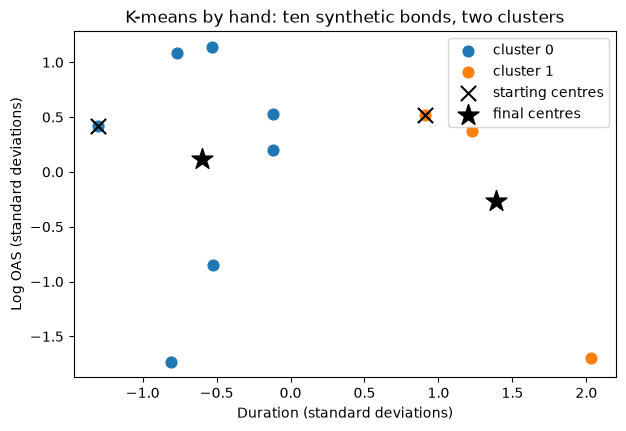

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for k, colour in zip(range(2), ["tab:blue", "tab:orange"]):
    members = small_z[labels_small == k]
    ax.scatter(members["duration"], members["log_oas"], s=60, color=colour, label=f"cluster {k}")
ax.scatter(start_centres[:, 0], start_centres[:, 1], marker="x", s=120, color="black", label="starting centres")
ax.scatter(new_centres[:, 0], new_centres[:, 1], marker="*", s=250, color="black", label="final centres")
ax.set_title("K-means by hand: ten synthetic bonds, two clusters")
ax.set_xlabel("Duration (standard deviations)")
ax.set_ylabel("Log OAS (standard deviations)")
ax.legend()
plt.show()

* Each final centre sits in the middle of its cluster, because it is the cluster's average.

On real data you do not hand K-means its starting centres. `KMeans` picks them by a randomized rule (k-means++), runs the loop from `n_init` different starts, and keeps the run with the lowest inertia. `random_state=SEED` fixes the starts, and `n_init=10` is always written out, because its default has changed between scikit-learn versions.

**How the course numbers clusters.** K-means numbers its clusters 0 to k-1 in the order it happens to find them. Another machine or another version of scikit-learn can find the same clusters and number them differently. So the course renumbers them by size: **cluster 0 is the largest**, cluster 1 the next, and so on; two clusters of the same size go in the order of the first row each holds. A cluster's number names a group; it is not a score and not an order of merit. Nothing printed today depends on the order K-means found them in.

Q. Write the numbering rule as a small function.

In [14]:
def number_by_size(labels):
    """Renumber cluster labels by cluster size, largest first, so cluster 0 is the largest.

    K-means numbers clusters in the order it finds them, which can change between machines and versions; the
    sizes do not. Two clusters of the same size are ordered by which one holds the earlier row.
    """
    labels = pd.Series(labels)
    # how many rows each label holds, and the position of the first row with each label
    sizes = labels.value_counts()
    first_seen = {label: position for position, label in enumerate(pd.unique(labels))}
    # largest first; a tie goes to the cluster seen first
    order = sorted(sizes.index, key=lambda label: (-sizes[label], first_seen[label]))
    renumber = {old: new for new, old in enumerate(order)}
    return labels.map(renumber).to_numpy()


print(number_by_size([7, 7, 3, 7, 3, 5]))
print(number_by_size([4, 9, 9, 4, 2]))

[0 0 1 0 1 2]
[0 1 1 0 2]


* Label 7 has three rows, so it becomes 0; label 3 has two, so it becomes 1; label 5 becomes 2.
* In the second example labels 4 and 9 both have two rows. Label 4 holds the first row, so it becomes 0 and label 9 becomes 1. The tie-break carries no meaning either: it only makes the numbering the same on every machine.

Q. Run K-means with four clusters on all the bonds, with the four columns as the file holds them: OAS in bp, duration in years, coupon in percent, rating score.

In [15]:
# K-means on the file's units, nothing scaled: ten starts, the course's seed
unscaled_model = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(bench[raw_columns])
bench["cluster_unscaled"] = number_by_size(unscaled_model.labels_)

# each cluster's size, and the smallest and largest OAS and duration inside it
bench.groupby("cluster_unscaled").agg(bonds=("oas", "size"), oas_min=("oas", "min"), oas_max=("oas", "max"),
                                      duration_min=("duration", "min"), duration_max=("duration", "max"))

,bonds,oas_min,oas_max,duration_min,duration_max
cluster_unscaled,,,,,
0,558,15,181,0.933,16.042
1,212,182,418,0.915,12.707
2,45,427,1004,1.201,9.536
3,6,1215,2074,1.546,5.207


* Read the OAS columns: 15 to 181 bp; 182 to 418 bp; 427 to 1,004 bp; 1,215 to 2,074 bp. The four clusters are four bands of OAS that do not overlap at all. Now read the duration columns: each of the three clusters with more than 6 bonds runs from 1.2 years or less to 9.5 years or more. Duration, coupon, and rating score barely moved the clusters. **Unscaled, the clusters are cut by OAS alone**, because OAS is the column with the biggest numbers.

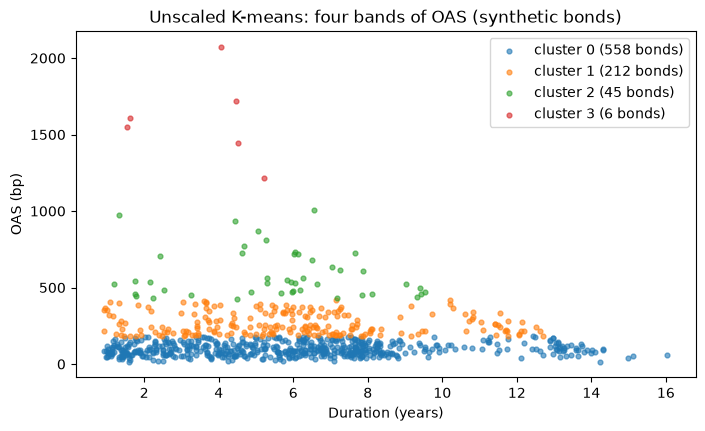

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for k in range(4):
    members = bench[bench["cluster_unscaled"] == k]
    ax.scatter(members["duration"], members["oas"], s=12, alpha=0.6, label=f"cluster {k} ({len(members)} bonds)")
ax.set_title("Unscaled K-means: four bands of OAS (synthetic bonds)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("OAS (bp)")
ax.legend()
plt.show()

* Horizontal bands: each cluster is a range of OAS across every duration. A reader told these were "duration groups", or "rating groups", would be told something the clusters cannot support.

## 12.4 Scaled: StandardScaler, Then K-Means

`StandardScaler` is the z-score of section 12.2 as a scikit-learn transformer: `fit` learns each column's mean and population standard deviation, `transform` subtracts and divides. One choice first: OAS in bp, or its log?

Q. How many standard deviations above the mean is the widest spread, in bp and in logs?

In [17]:
for column in ["oas", "log_oas"]:
    z = (bench[column] - bench[column].mean()) / bench[column].std(ddof=0)
    print(f"{column:8} widest bond: {z.max():.2f} standard deviations above the mean")

oas      widest bond: 10.22 standard deviations above the mean
log_oas  widest bond: 3.74 standard deviations above the mean


* In bp the widest bond sits 10.22 standard deviations above the mean; in logs, 3.74. Scaling puts columns on one scale, but it does not change their shape: a column with a long right tail keeps it, and because K-means squares distances, a few far-out bonds pull hard on a centre. Days 4 and 5 modelled log OAS because the generator multiplies; the clusters use log OAS for the same reason.

Q. Scale the four columns with `StandardScaler`.

In [18]:
from sklearn.preprocessing import StandardScaler

# fitted on all 821 bonds: clustering reports nothing on held-out rows, so there is no test row to leak into
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bench[features])

# every column now has mean 0 and standard deviation 1 (population, ddof=0); + 0.0 shows -0.0 as 0.0
by_hand = (bench[features] - bench[features].mean()) / bench[features].std(ddof=0)
print(f"equal to the z-score by hand within 1e-12: {np.abs(X_scaled - by_hand.to_numpy()).max() < 1e-12}")
pd.DataFrame({"mean": X_scaled.mean(axis=0), "std (ddof=0)": X_scaled.std(axis=0)}, index=features).round(4) + 0.0

equal to the z-score by hand within 1e-12: True


,mean,std (ddof=0)
log_oas,0.0,1.0
duration,0.0,1.0
coupon,0.0,1.0
score,0.0,1.0


* Means 0 and standard deviations 1, exactly the z-scores by hand. `X_scaled` is a numpy array: the scaler returns numbers without column names.

Q. Fit K-means with four clusters on the scaled columns.

In [19]:
# the same K-means as before, now on scaled columns
model = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_scaled)
bench["cluster"] = number_by_size(model.labels_)
print(f"inertia: {model.inertia_:.2f} (in squared standard deviations)")

bench.groupby("cluster").agg(bonds=("oas", "size"), oas_min=("oas", "min"), oas_max=("oas", "max"),
                             duration_min=("duration", "min"), duration_max=("duration", "max"),
                             score_min=("score", "min"), score_max=("score", "max"))

inertia: 1141.83 (in squared standard deviations)


,bonds,oas_min,oas_max,duration_min,duration_max,score_min,score_max
cluster,,,,,,,
0,278,15,143,0.933,9.629,1,10
1,239,81,354,0.927,8.344,6,15
2,175,15,294,6.445,16.042,1,14
3,129,197,2074,0.915,11.766,10,18


* 278, 239, 175, 129 bonds. Now the ranges overlap in every column: no single column cuts these clusters. Each cluster is a region of four columns at once, and a bond belongs to the cluster whose centre is nearest across all four.

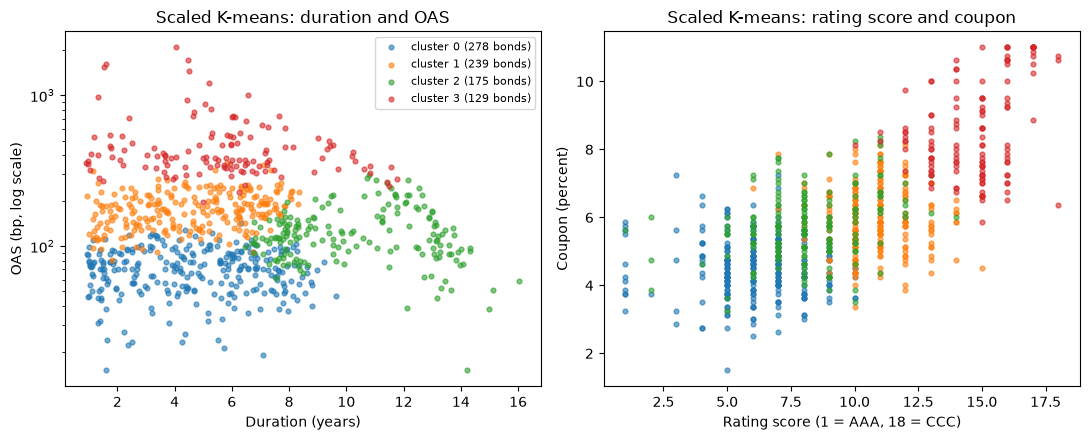

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for k in range(4):
    members = bench[bench["cluster"] == k]
    ax1.scatter(members["duration"], members["oas"], s=12, alpha=0.6, label=f"cluster {k} ({len(members)} bonds)")
    ax2.scatter(members["score"], members["coupon"], s=12, alpha=0.6, label=f"cluster {k}")
ax1.set_yscale("log")
ax1.set_title("Scaled K-means: duration and OAS")
ax1.set_xlabel("Duration (years)")
ax1.set_ylabel("OAS (bp, log scale)")
ax1.legend(fontsize=8)
ax2.set_title("Scaled K-means: rating score and coupon")
ax2.set_xlabel("Rating score (1 = AAA, 18 = CCC)")
ax2.set_ylabel("Coupon (percent)")
plt.tight_layout()
plt.show()

* Two views of the same four clusters (synthetic bonds). On the left, one cluster sits to the right, at long durations, and the others overlap in OAS. On the right, rating score and coupon separate other clusters. No two-column picture shows all four columns at once, so each chart shows part of what K-means used.

## 12.5 The Elbow and the Silhouette

K-means needs k before it starts, and the data does not come with one. Two measures help.

**Inertia** falls every time k rises, because more centres always sit closer to the rows: with 821 clusters, one bond each, it would be 0. So the smallest inertia cannot choose k. The **elbow** is the k after which an extra cluster stops lowering the inertia by much: on a chart of inertia against k, the place where the curve bends.

The **silhouette** asks, for each row, whether it sits nearer its own cluster than the next one:

* a = the average distance from the row to the other rows of its own cluster
* b = the average distance from the row to the rows of the nearest other cluster
* silhouette = (b - a) / the larger of a and b

It runs from -1 to 1. Near 1, the row is much closer to its own cluster; near 0, it sits on a border; below 0, it is closer to another cluster than to its own. `silhouette_score` is the average over all rows.

Q. Compute the silhouette of the first bond by hand, for the four clusters of section 12.4.

In [21]:
from sklearn.metrics import silhouette_samples, silhouette_score

# the first bond's distance to every bond, in scaled units, and every bond's cluster
d_first = np.sqrt(((X_scaled - X_scaled[0]) ** 2).sum(axis=1))
cluster_of = bench["cluster"].to_numpy()

# a: the average distance to the other bonds of its own cluster (minus 1 leaves the bond itself out)
same_cluster = cluster_of == cluster_of[0]
a_own = d_first[same_cluster].sum() / (same_cluster.sum() - 1)
# b: the smallest average distance to the bonds of another cluster
b_other = min(d_first[cluster_of == k].mean() for k in range(4) if k != cluster_of[0])
silhouette_first = (b_other - a_own) / max(a_own, b_other)

print(f"a = {a_own:.4f}, b = {b_other:.4f}, silhouette of the first bond = {silhouette_first:.4f}")
print(f"silhouette_samples agrees within 1e-12: {abs(silhouette_first - silhouette_samples(X_scaled, cluster_of)[0]) < 1e-12}")
print(f"silhouette_score, the average over all {len(bench)} bonds: {silhouette_score(X_scaled, cluster_of):.4f}")

a = 1.4057, b = 1.6378, silhouette of the first bond = 0.1417
silhouette_samples agrees within 1e-12: True
silhouette_score, the average over all 821 bonds: 0.2930


* The first bond sits 1.4057 from its own cluster on average and 1.6378 from the nearest other, so its silhouette is 0.1417: on its own side, not far from the border. The average over all bonds is 0.2930.

Q. Add `elbow_table` to `mlkit.py`: inertia and silhouette for each k, so k is chosen by looking at both.

In [22]:
%%writefile -a mlkit.py


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")

Appending to mlkit.py


* The docstring says the input must already be scaled, and why: K-means measures distance, so units decide the clusters.
* `KMeans(n_clusters=k, n_init=10, random_state=seed)` is the course's K-means, with `n_init` written out. The table is indexed by k, so `table.loc[4]` reads the row for four clusters.
* It refuses an empty list of k, a k below 2 (one cluster has no silhouette), and a k as large as the number of rows.

Q. Add the three tests: the shape of the table, inertia falling as k rises, and agreement with `KMeans` and `silhouette_score` run directly.

In [23]:
%%writefile -a test_mlkit.py


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def scaled_bonds() -> np.ndarray:
    """log_oas, duration, coupon, and rating score of the 821 bonds, each scaled to mean 0 and standard deviation 1
    (StandardScaler, fitted on every bond: nothing is tested on held-out rows when clustering)."""
    bench = read_bench()
    return StandardScaler().fit_transform(bench[["log_oas", "duration", "coupon", "score"]])


def test_elbow_table_columns_and_ks():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert list(table.index) == list(range(2, 9))
    assert table.index.name == "k"
    assert list(table.columns) == ["inertia", "silhouette"]
    assert table["silhouette"].between(-1, 1).all()
    with pytest.raises(ValueError):
        mlkit.elbow_table(scaled_bonds(), [1, 3])


def test_elbow_inertia_decreases():
    table = mlkit.elbow_table(scaled_bonds(), range(2, 9))
    assert table["inertia"].is_monotonic_decreasing


def test_elbow_matches_kmeans():
    X = scaled_bonds()
    table = mlkit.elbow_table(X, [4])
    model = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X)
    assert table.loc[4, "inertia"] == pytest.approx(model.inertia_, abs=1e-9)
    assert table.loc[4, "silhouette"] == pytest.approx(silhouette_score(X, model.labels_), abs=1e-12)

Appending to test_mlkit.py


* `scaled_bonds` is a helper: the four columns of every bond, scaled exactly as in section 12.4.

Q. Reload the module and run all the tests.

In [24]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"elbow_table in mlkit: {hasattr(mlkit, 'elbow_table')}")

elbow_table in mlkit: True


In [25]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..................................................                       [100%]
50 passed in 3.56s



* `50 passed`: the 47 tests of days 1 to 11 and today's three.

Q. Compute the inertia and the silhouette for k = 2 to 8 on the scaled bonds.

In [26]:
# K-means for each k from 2 to 8, ten starts each
elbow = mlkit.elbow_table(X_scaled, range(2, 9))
elbow.round({"inertia": 2, "silhouette": 4})

,inertia,silhouette
k,,
2,1897.58,0.3689
3,1470.38,0.2896
4,1141.83,0.2930
5,987.53,0.2899
6,868.09,0.2830
7,763.91,0.2888
8,692.33,0.2915


Q. Draw the two measures side by side.

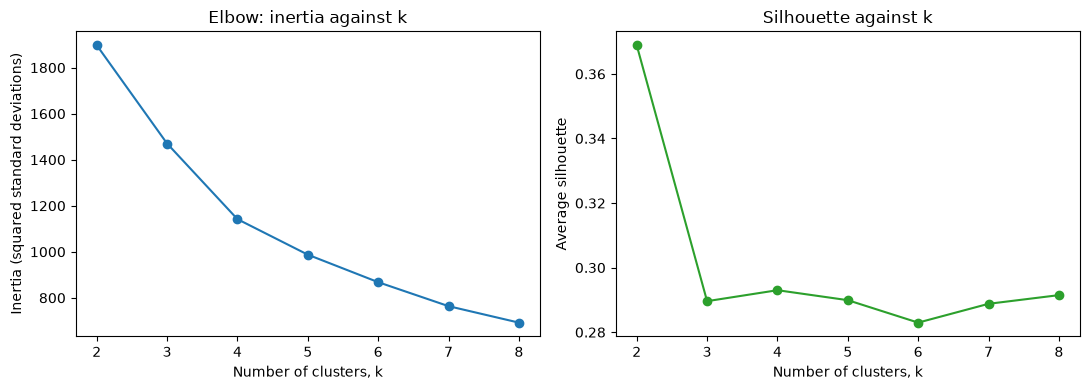

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(elbow.index, elbow["inertia"], marker="o")
ax1.set_title("Elbow: inertia against k")
ax1.set_xlabel("Number of clusters, k")
ax1.set_ylabel("Inertia (squared standard deviations)")
ax2.plot(elbow.index, elbow["silhouette"], marker="o", color="tab:green")
ax2.set_title("Silhouette against k")
ax2.set_xlabel("Number of clusters, k")
ax2.set_ylabel("Average silhouette")
plt.tight_layout()
plt.show()

## 12.6 Choosing k as a Judgement

Q. How much does each extra cluster lower the inertia?

In [28]:
# the fall in inertia from one k to the next
elbow.assign(fall_in_inertia=-elbow["inertia"].diff()).round({"inertia": 2, "silhouette": 4, "fall_in_inertia": 2})

,inertia,silhouette,fall_in_inertia
k,,,
2,1897.58,0.3689,NaN
3,1470.38,0.2896,427.20
4,1141.83,0.2930,328.55
5,987.53,0.2899,154.29
6,868.09,0.2830,119.44
7,763.91,0.2888,104.19
8,692.33,0.2915,71.58


* The inertia falls by 427.20 from 2 to 3, 328.55 from 3 to 4, 154.29 from 4 to 5, 119.44 from 5 to 6. The falls shrink, but there is no sharp corner: the curve bends gradually, and the bend is somewhere around 4.
* The silhouette is highest at k = 2 (0.3689). From 3 to 8 it stays between 0.2830 and 0.2930, with its highest value at k = 4.

Q. What does k = 2 separate, against k = 4?

In [29]:
# two clusters, numbered by size, and the average of each column in the file's units
two_clusters = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_scaled)
bench["cluster_k2"] = number_by_size(two_clusters.labels_)
bench.groupby("cluster_k2")[raw_columns].mean().round(2).assign(bonds=bench["cluster_k2"].value_counts())

,oas,duration,coupon,score,bonds
cluster_k2,,,,,
0,96.22,6.00,5.01,7.34,538
1,336.60,5.95,7.45,12.88,283


* With two clusters, the 538 and 283 bonds have average durations of 6.00 and 5.95 years: the split is by spread, coupon, and rating score (96.2 against 336.6 bp), and duration plays no part. Four clusters add a group set apart by duration (section 12.4's chart).

**The judgement.** The course takes **k = 4**: the inertia curve bends there, its silhouette is the highest of any k above 2, and it shows a difference in duration that two clusters hide. That is a choice with reasons, not a number the data revealed. An analyst could take k = 2 for the higher silhouette, or k = 5 for a finer split, and give reasons just as good. The two charts support a choice; neither discovers a true number of clusters.

There is a fact behind the weak structure, too. The generator draws each issuer's rating, each bond's maturity, and a coupon near the bond's yield, and never assigns a bond to a group. Silhouettes between 0.28 and 0.37 say the clusters overlap: they cut a cloud of bonds into regions, and the regions are a convenient way to describe the cloud, not groups that were waiting to be found.

## 12.7 Clusters Described, Never Ranked

A cluster's output gets a name in this course, and only a name the course allows. For K-means on the synthetic bonds the allowed names are "cluster", "cluster 2", and "a group of similar rows in an invented dataset", described by how many bonds it holds and the averages of its columns.

A cluster is never a recommendation, never a ranking, and never a quality label. No cluster is called good or bad, safe or risky, cheap or rich, and none is presented as a peer group of real issuers. A cluster says that some invented bonds sit near each other in four scaled columns; it says nothing about what anyone should hold.

Q. Describe each cluster by its count and the averages of its columns, in the file's units.

In [30]:
# counts and averages per cluster: OAS in bp, duration in years, coupon in percent, rating score 1 to 18
profile = bench.groupby("cluster").agg(
    bonds=("oas", "size"),
    oas_bp=("oas", "mean"),
    duration_years=("duration", "mean"),
    coupon_pct=("coupon", "mean"),
    rating_score=("score", "mean"),
    investment_grade_pct=("grade", lambda grade: 100 * (grade == "Investment Grade").mean()),
)
profile.round({"oas_bp": 1, "duration_years": 2, "coupon_pct": 2, "rating_score": 2, "investment_grade_pct": 1})

,bonds,oas_bp,duration_years,coupon_pct,rating_score,investment_grade_pct
cluster,,,,,,
0,278,70.8,4.65,4.57,6.16,100.0
1,239,178.5,4.59,5.96,10.74,45.6
2,175,126.3,10.32,5.75,8.14,86.9
3,129,485.0,5.55,8.55,14.66,0.8


* **Cluster 0**, 278 bonds: average OAS 70.8 bp, duration 4.65 years, coupon 4.57 percent, rating score 6.16 (nearest rating A), 100.0 percent investment grade.
* **Cluster 1**, 239 bonds: average OAS 178.5 bp, duration 4.59 years, coupon 5.96 percent, rating score 10.74 (nearest rating BB+), 45.6 percent investment grade.
* **Cluster 2**, 175 bonds: average OAS 126.3 bp, duration 10.32 years, coupon 5.75 percent, rating score 8.14 (nearest rating BBB+), 86.9 percent investment grade.
* **Cluster 3**, 129 bonds: average OAS 485.0 bp, duration 5.55 years, coupon 8.55 percent, rating score 14.66 (nearest rating B), 0.8 percent investment grade.

* Cluster 2 is the one set apart by duration (10.32 years on average). Cluster 3 has the widest average OAS and cluster 0 the tightest. These sentences describe four groups of invented bonds; they do not say one group is better than another.
* An average of OAS is pulled up by the few very wide spreads in a cluster. Tomorrow's profile uses medians, in the data's own units, with a function written for it.

## Excel Side by Side

Excel has no K-means function, no silhouette function, and no elbow chart, so the clusters are fitted in Python. What Excel can do is every step of one K-means round: scale, measure the distance to each centre, pick the nearest, and average. The four scaled columns of the 821 bonds went onto a sheet named `bonds` (log OAS, duration, coupon, score in A to D, rows 2 to 822), with the four centres from Python, in the course's numbering, in `T1:W4`. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Scale a column | `StandardScaler().fit_transform(...)` | `=STANDARDIZE(A2,AVERAGE(A$2:A$822),STDEV.P(A$2:A$822))` in G2, filled right to J and down | equal to `StandardScaler` within 1e-9 |
| Scale with the sample standard deviation | not what `StandardScaler` does | `=STANDARDIZE(A2,AVERAGE(A$2:A$822),STDEV.S(A$2:A$822))` | every z-score smaller by the factor 1.00061 |
| Distance to centre 0 | `np.sqrt(((X - centre) ** 2).sum(axis=1))` | `=SQRT(SUMXMY2($G2:$J2,$T$1:$W$1))` in L2; M, N, O use rows 2, 3, 4 of the centres | one column per centre |
| Nearest centre | `distances.argmin(axis=1)` | `=MATCH(MIN(L2:O2),L2:O2,0)-1` in P2, filled down | the course's cluster for 821 of 821 bonds |
| Update: average per cluster | `groupby(cluster).mean()` | `=AVERAGEIF($P$2:$P$822,$S7,G$2:G$822)` | equal to pandas within 1e-9 |
| Cluster sizes | `value_counts()` | `=COUNTIF($P$2:$P$822,$S7)` | 278, 239, 175, 129 |
| Distance between two bonds | section 12.2 | `=SQRT(SUMXMY2(A2:D2,A3:D3))` | 39.02 in the file's units; 0.6244 scaled |

**`STANDARDIZE` with `STDEV.P`.** `STANDARDIZE(x, mean, standard_dev)` computes (x - mean) / standard_dev. With `STDEV.P`, the population standard deviation, it gives `StandardScaler`'s numbers. With `STDEV.S`, the sample standard deviation, which divides by n - 1, every z-score is smaller by the factor square root of n / (n - 1), here square root of 821 / 820. Small, but not equal, and a check at 1e-9 would fail.

**`SUMXMY2` is the squared distance.** It sums the squared differences of two ranges, so `SQRT(SUMXMY2(row, centre))` is the Euclidean distance. The dollar signs lock the columns of the row and the whole centre, so filling down moves only the row.

**`MATCH(MIN(...))` is the assignment step.** `MIN(L2:O2)` finds the shortest of the four distances and `MATCH(..., 0)` its position, 1 to 4; minus 1 gives the cluster number, 0 to 3, because the centres were pasted in the course's order. `AVERAGEIF` over column P is the update step: it gives each cluster's average of each scaled column.

**Why the averages are not exactly `cluster_centers_`.** scikit-learn stops its loop once the centres move less than a small tolerance (`tol`), so its `cluster_centers_` can sit a little away from the averages of their final members: here by at most 0.003 in scaled units. One more round from those averages would move 0 bonds. `AVERAGEIF` gives the averages, so Python's averages are the fair comparison.

In [31]:
# Excel's averages per cluster (AVERAGEIF on the scaled columns, T7:W10), from the day's Excel check
excel_averages = pd.DataFrame([[-0.9392172727819537, -0.4093073958366741, -0.7758507492936222, -0.9006391750391239], [0.3522732311578557, -0.42839099036129485, 0.06720191611283989, 0.4336551222780674], [-0.17926072143776473, 1.3334259317506687, -0.06105372685064233, -0.3238981821810295], [1.6145715181261027, -0.13315221176296646, 1.630307384120315, 1.57687052959766]], columns=features)
python_averages = pd.DataFrame(X_scaled, columns=features).groupby(bench["cluster"]).mean()
print(f"AVERAGEIF equal to pandas within 1e-9: {np.abs(excel_averages.to_numpy() - python_averages.to_numpy()).max() < 1e-9}")

# the assignment step in Python: the distance from every bond to each centre (in the course's numbering), then the nearest
order = pd.Series(model.labels_).value_counts().index   # K-means' own labels, largest cluster first
centres_scaled = model.cluster_centers_[order]
# X_scaled[:, None, :] - centres_scaled[None, :, :] has one row per bond, one block per centre, one entry per column
distance_to_centres = np.sqrt(((X_scaled[:, None, :] - centres_scaled[None, :, :]) ** 2).sum(axis=2))
nearest_centre = distance_to_centres.argmin(axis=1)
print(f"nearest centre equals the cluster for {(nearest_centre == bench['cluster']).sum()} of {len(bench)} bonds "
      f"(Excel's MATCH: 821 of 821)")

AVERAGEIF equal to pandas within 1e-9: True
nearest centre equals the cluster for 821 of 821 bonds (Excel's MATCH: 821 of 821)


* Every bond's nearest centre is its cluster, in Python and in Excel, and Excel's averages are pandas' averages. Excel cannot choose the starting centres or run ten starts, but it can check every step of a round.

## Save the Day with Git

Today's work folder is new, so it gets its own repository, the module and its tests are committed, and the experiment log starts again. Clustering has no test rows, so today's log has its own columns: the features, k, the number of rows, the inertia, and the silhouette.

Q. Make the work folder a repository.

In [32]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [33]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_12_i23q_2t9 and nowhere else


Q. Tell Git which files never to track.

In [34]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Commit the module, its tests, and `.gitignore`.

In [35]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Add elbow_table: inertia and silhouette for each k, with three tests"
!git -C "{work}" log --oneline

b91bd1d Add elbow_table: inertia and silhouette for each k, with three tests


Q. Write the chosen clustering to `results.csv` and commit it.

In [36]:
# one row per clustering: what was clustered, k, and the two measures (inertia 2 decimals, silhouette 4)
results = pd.DataFrame([{
    "model": "kmeans_scaled",
    "features": " ".join(features),
    "k": 4,
    "rows": len(bench),
    "inertia": round(elbow.loc[4, "inertia"], 2),
    "silhouette": round(elbow.loc[4, "silhouette"], 4),
}])
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,k,rows,inertia,silhouette
kmeans_scaled,log_oas duration coupon score,4,821,1141.8300,0.2930



In [37]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: K-means, k = 4, on four scaled columns"

Q. A colleague asks how two clusters compare. Add a row for k = 2 to the working file, then compare the working file with the last commit.

In [38]:
# the same columns for k = 2, appended to the working file only
k2_row = {"model": "kmeans_scaled", "features": " ".join(features), "k": 2, "rows": len(bench),
          "inertia": round(elbow.loc[2, "inertia"], 2), "silhouette": round(elbow.loc[2, "silhouette"], 4)}
results = pd.concat([results, pd.DataFrame([k2_row])], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print("the working file:")
print((work / "results.csv").read_text(encoding="utf-8"))

the working file:
model,features,k,rows,inertia,silhouette
kmeans_scaled,log_oas duration coupon score,4,821,1141.8300,0.2930
kmeans_scaled,log_oas duration coupon score,2,821,1897.5800,0.3689



In [39]:
# the file as the last commit holds it: HEAD:results.csv names a file inside a commit
!git -C "{work}" show HEAD:results.csv

model,features,k,rows,inertia,silhouette
kmeans_scaled,log_oas duration coupon score,4,821,1141.8300,0.2930


* `git show HEAD:results.csv` prints the file as the last commit saved it, without touching the working file: one row, k = 4. The working file has two. This is how you check what the log said before a change, or recover a number you overwrote.

Q. Commit the second row.

In [40]:
!git -C "{work}" status --short
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: k = 2 beside k = 4"
!git -C "{work}" log --oneline

 M results.csv
?? benchmark.csv
?? course4_excel_reference.csv
?? credit_card_default.csv
?? ratings.csv
?? treasury_par_yields.csv


51f4ccd Experiment log: k = 2 beside k = 4
a047a43 Experiment log: K-means, k = 4, on four scaled columns
b91bd1d Add elbow_table: inertia and silhouette for each k, with three tests


* Three commits: the code, then the chosen clustering, then the comparison.

## Bring It Home

Add today's function and tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code. No new data file is needed: the tests read `benchmark.csv` and `ratings.csv`, which you copied on day 1.

**Step 1.** Open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the `%%writefile -a mlkit.py` cell of section 12.5, without its first line, at the end of `mlkit.py`; do the same for the `%%writefile -a test_mlkit.py` cell. Save both.

**Step 3.** Run the tests.

```powershell
& "$HOME\projects\python-fixed-income\.venv\Scripts\Activate.ps1"
python -m pytest -q test_mlkit.py
```

The last line says `50 passed`.

**Step 4.** Read what changed, then commit the code only.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "Add elbow_table: inertia and silhouette for each k, with three tests"
git log --oneline -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what changes when a method has no target: no error to measure, no test rows, and a judgement at the end.
* Measure a Euclidean distance between bonds, and show that unscaled columns let the biggest unit decide it.
* Run K-means by hand (start, assign, update, repeat) and match `KMeans`.
* Scale with `StandardScaler`, and match it in Excel with `STANDARDIZE` and `STDEV.P`.
* Compute the elbow and the silhouette with `elbow_table`, and compute one silhouette by hand.
* Choose k as a judgement with reasons, and say what another reasonable choice would be.
* Number clusters by size, and describe them by counts and averages without ranking them.
* Compare the working file with the last commit using `git show HEAD:results.csv`.

Tomorrow, day 13, builds clusters from the bottom up with hierarchical clustering on the 150 issuers, draws the dendrogram, and profiles the clusters with medians in the data's own units.

## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, scales the four columns, fits section 12.4's four clusters, defines `number_by_size`, and defines `check`, a small function that marks your answers.

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# the 821 synthetic bonds with rating score, grade, and log OAS
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
bench["log_oas"] = np.log(bench["oas"])
features = ["log_oas", "duration", "coupon", "score"]

# section 12.4: the four columns scaled on every bond, then K-means with four clusters
X_scaled = StandardScaler().fit_transform(bench[features])
labels = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_scaled).labels_


def number_by_size(labels):
    """Renumber cluster labels by size, largest first; a tie goes to the cluster holding the earlier row."""
    labels = pd.Series(labels)
    sizes = labels.value_counts()
    first_seen = {label: position for position, label in enumerate(pd.unique(labels))}
    order = sorted(sizes.index, key=lambda label: (-sizes[label], first_seen[label]))
    return labels.map({old: new for new, old in enumerate(order)}).to_numpy()


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Add `amount_outstanding` (in dollars) as a fifth column. Scale the five columns with `StandardScaler`, fit K-means with four clusters (`n_init=10`, `random_state=SEED`), and store the average silhouette in **ex1_silhouette** and the number of bonds in the largest cluster in **ex1_largest**.

In [42]:
ex1_silhouette = ...
ex1_largest = ...

In [43]:
check("Exercise 1 the silhouette", ex1_silhouette, 0.21992362045331745)
check("Exercise 1 the largest cluster", ex1_largest, 283)

Exercise 1 the silhouette: not attempted yet
Exercise 1 the largest cluster: not attempted yet


### Exercise 2

Q. Cluster the investment grade bonds only (`grade == "Investment Grade"`). Scale the four columns on those bonds, run `mlkit.elbow_table` for k = 2 to 8, and store the k with the highest silhouette in **ex2_best_k** (a whole number) and the silhouette at k = 4 in **ex2_silhouette_4**.

In [44]:
ex2_best_k = ...
ex2_silhouette_4 = ...

In [45]:
check("Exercise 2 the k with the highest silhouette", ex2_best_k, 2)
check("Exercise 2 the silhouette at k = 4", ex2_silhouette_4, 0.23440881348670242)

Exercise 2 the k with the highest silhouette: not attempted yet
Exercise 2 the silhouette at k = 4: not attempted yet


### Exercise 3

Q. Add a function to your module. `cluster_sizes(labels)` returns a Series of how many rows each cluster holds, indexed by cluster (index named `cluster`, sorted) and named `count`, and raises `ValueError` on an empty input. Write the docstring first. Then add `test_cluster_sizes_hand_and_empty`, which checks six labels counted by hand and that an empty input raises. Run pytest, reload the module, and store `mlkit.cluster_sizes(number_by_size(labels)).to_dict()` in **ex3_sizes**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [46]:
%%writefile -a mlkit.py


# Exercise 3: write cluster_sizes(labels) below this line

Appending to mlkit.py


In [47]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_cluster_sizes_hand_and_empty() below this line

Appending to test_mlkit.py


In [48]:
# run pytest, reload the module, then call your function
ex3_sizes = ...

In [49]:
check("Exercise 3 cluster_sizes", ex3_sizes, {0: 278, 1: 239, 2: 175, 3: 129})

Exercise 3 cluster_sizes: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that groups bonds by OAS and duration, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Group bonds with K-means on OAS (bp) and duration (years).

    Both columns are scaled to mean 0 and standard deviation 1 (StandardScaler, fitted on the bonds given)
    before K-means, so a bp and a year count alike in the distance.
    Model: KMeans(n_clusters=k, n_init=10, random_state=SEED).
    Returns: the cluster of each bond, and the features K-means was fitted on.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns four clusters, comes with a confident comment, and contains one bug.

In [50]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def cluster_bonds(bonds, k=4):
    """Group bonds with K-means on OAS (bp) and duration (years).

    Both columns are scaled to mean 0 and standard deviation 1 (StandardScaler, fitted on the bonds given)
    before K-means, so a bp and a year count alike in the distance.
    Model: KMeans(n_clusters=k, n_init=10, random_state=SEED).
    Returns: the cluster of each bond, and the features K-means was fitted on.
    """
    features = bonds[["oas", "duration"]].to_numpy(dtype=float)
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(features)
    # the clusters are duration groups: short, intermediate, long, and very long bonds
    return model.labels_, features

Q. Before you run the next cell: will the four clusters differ mostly in duration, as the comment says, or in something else?

In [51]:
# the clusters of cluster_bonds, numbered by size: the range of OAS and of duration in each
ai_labels, ai_features = cluster_bonds(bench)
bench.assign(ai_cluster=number_by_size(ai_labels)).groupby("ai_cluster").agg(
    bonds=("oas", "size"), oas_min=("oas", "min"), oas_max=("oas", "max"),
    duration_min=("duration", "min"), duration_max=("duration", "max"))

,bonds,oas_min,oas_max,duration_min,duration_max
ai_cluster,,,,,
0,558,15,181,0.933,16.042
1,212,182,418,0.915,12.707
2,45,427,1004,1.201,9.536
3,6,1215,2074,1.546,5.207


Q. Test the function against its docstring before you trust it.

In [52]:
# the test, written from the docstring before the code is trusted
ai_labels, ai_features = cluster_bonds(bench)
fitted_on = np.asarray(ai_features, dtype=float)

# the docstring promises scaled features: every column with mean 0 and standard deviation 1 (ddof=0)
column_means, column_stds = fitted_on.mean(axis=0), fitted_on.std(axis=0)
assert np.allclose(column_means, 0, atol=1e-9), f"the features K-means saw are not scaled: column means {column_means.round(2).tolist()}"
assert np.allclose(column_stds, 1), f"the features K-means saw are not scaled: standard deviations {column_stds.round(2).tolist()}"
print("cluster_bonds fits K-means on scaled features")

AssertionError: the features K-means saw are not scaled: column means [179.08, 5.98]

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the sizes of the fixed function's four clusters, largest first, as a list of whole numbers, in **ex4_sizes**: `sorted(np.bincount(cluster_bonds(bench)[0]).tolist(), reverse=True)`.

In [53]:
# fix the function above and run the test again, then store the answer
ex4_sizes = ...

In [54]:
check("Exercise 4 the fixed function's cluster sizes", ex4_sizes, [368, 340, 104, 9])

Exercise 4 the fixed function's cluster sizes: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```